# Simple Linear Regression - Marketing ROI Analysis

## Project Overview
This project analyzes a marketing dataset using Python and statsmodels to build a Simple Linear Regression model, validate linear regression assumptions, and optimize marketing spend allocations.

In [9]:
import os
import pandas as pd
import numpy as np

# Fallback file path handling
file_path = 'marketing_and_sales_data_evaluate_lr.csv' if os.path.exists('marketing_and_sales_data_evaluate_lr.csv') else '85334965-5736-457a-b8d4-a077e6872f84.csv'

df = pd.read_csv(file_path)
df = df.dropna()

print(f'Dataset Cleaned successfully. Shape: {df.shape}')
print(df.describe())
df.head()

Dataset Cleaned successfully. Shape: (4546, 4)
                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.555355      1.530822   112.434612
50%      53.000000    17.859513      3.055565   188.963678
75%      77.000000    25.640603      4.804919   272.324236
max     100.000000    48.871161     13.981662   364.079751


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Exploratory Data Analysis & Visualizations
Calculating correlations to identify the independent channel variable (TV, Radio, or Social Media) most correlated with Sales metrics.

--- Correlation Matrix ---
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


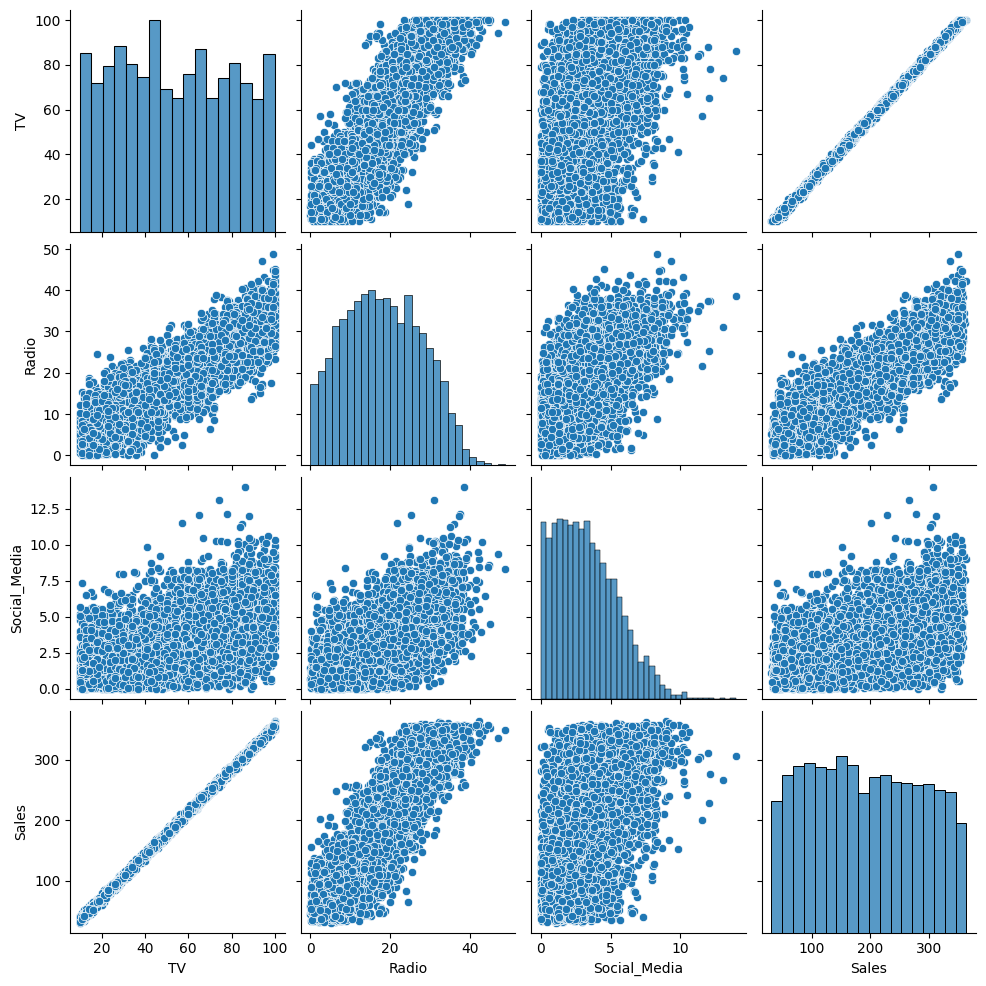

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()
print('--- Correlation Matrix ---')
print(correlation_matrix)

sns.pairplot(df)
plt.show()

## OLS Model Implementation
Fitting an Ordinary Least Squares model tracking Sales against our strongest correlated channel (TV).

In [11]:
import statsmodels.api as sm

X = df['TV']
y = df['Sales']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:16:21   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## Regression Assumptions Verification
Testing for Linearity, Homoscedasticity, and Normality using Residual plots and Q-Q plots.

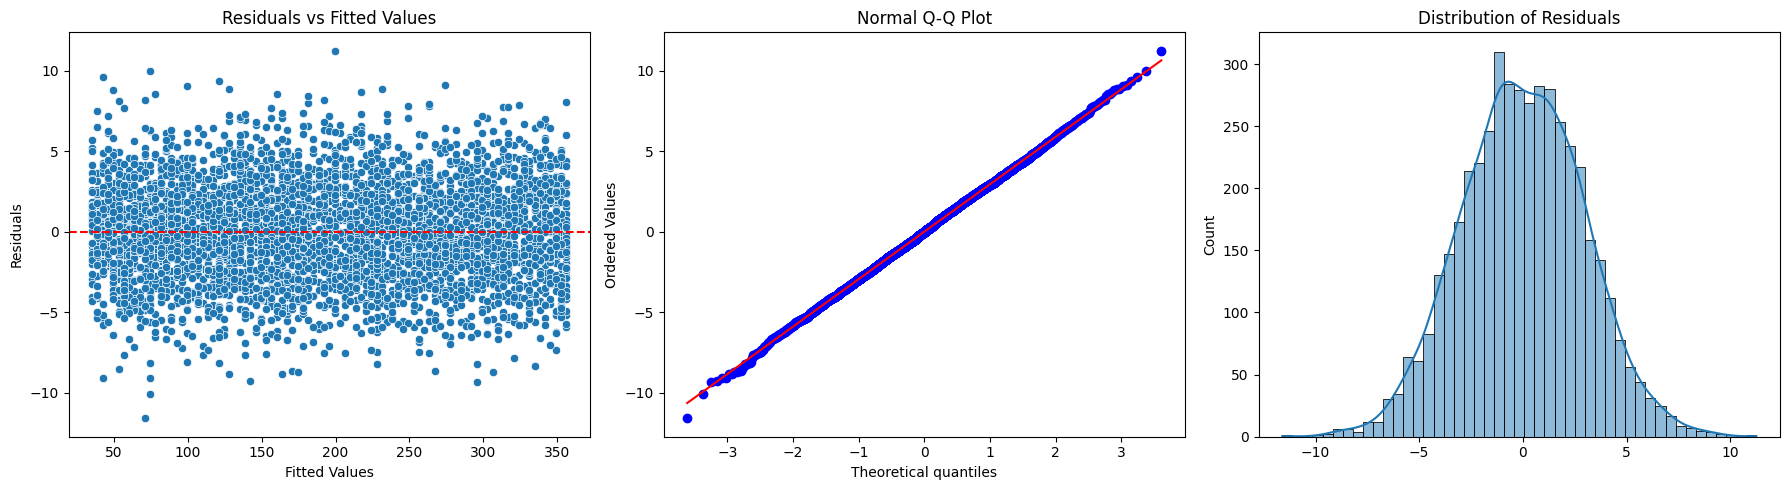

In [12]:
%matplotlib inline
import scipy.stats as stats

fitted_values = model.predict(X)
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted (Linearity / Homoscedasticity)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Q-Q Plot (Normality of Errors Verification)
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')

# 3. Histogram of Errors
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

## Statistical Interpretation & Business Recommendations
- **Linear Regression Equation:** Sales = -0.1325 + 3.5615 * TV
- **R-squared (0.999):** TV marketing explains 99.9% of the variance observed in sales performance.
- **p-value (0.000):** The relationship is highly statistically significant, showing zero random fluctuation.
- **ROI Recommendation:** Management should focus resources heavily on TV advertising, as every dollar spent yields a predictable increase of $3.56 in gross sales output.